In [1]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from sklearn.manifold import MDS
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
import plotly.express as px

In [2]:
data_merged = pd.read_csv("../data/merged.csv")
data_merged.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,G3_mat,failures_por,paid_por,absences_por,G1_por,G2_por,G3_por,reussite_mat,reussite_por,reussite
0,GP,F,15,R,GT3,T,1,1,at_home,other,...,10.0,0.0,yes,4.0,13.0,13.0,13.0,1,1,1
1,GP,F,15,R,GT3,T,1,1,other,other,...,NaN,1.0,no,2.0,8.0,9.0,9.0,0,0,0
2,GP,F,15,R,GT3,T,1,1,other,other,...,5.0,0.0,no,2.0,13.0,11.0,11.0,0,1,0
3,GP,F,15,R,GT3,T,2,2,at_home,other,...,13.0,0.0,no,8.0,14.0,13.0,12.0,1,1,1
4,GP,F,15,R,GT3,T,2,4,services,health,...,8.0,0.0,no,2.0,10.0,11.0,10.0,0,1,0


In [3]:
data_numeric = data_merged

In [4]:
data = data_merged.copy().select_dtypes(include='number')
data = data.dropna()

In [5]:
data.head()

,age,Medu,Fedu,traveltime,studytime,failures_mat,famrel,freetime,goout,Dalc,...,G2_mat,G3_mat,failures_por,absences_por,G1_por,G2_por,G3_por,reussite_mat,reussite_por,reussite
0,15,1,1,2,4,1.0,3,1,2,1,...,10.0,10.0,0.0,4.0,13.0,13.0,13.0,1,1,1
2,15,1,1,1,2,2.0,3,3,4,2,...,6.0,5.0,0.0,2.0,13.0,11.0,11.0,0,1,0
3,15,2,2,1,1,0.0,4,3,1,1,...,13.0,13.0,0.0,8.0,14.0,13.0,12.0,1,1,1
4,15,2,4,1,3,0.0,4,3,2,1,...,9.0,8.0,0.0,2.0,10.0,11.0,10.0,0,1,0
5,15,3,3,2,3,2.0,4,2,1,2,...,10.0,10.0,0.0,2.0,13.0,13.0,13.0,1,1,1


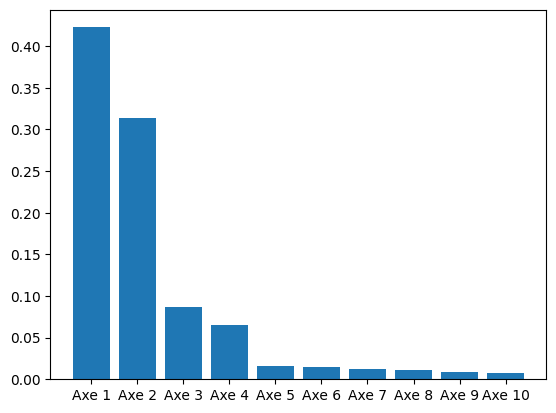

array([0.42259605, 0.73597554, 0.82315895, 0.88791795, 0.90438153,
       0.91901139, 0.93145934, 0.94281884, 0.95190578, 0.95991679])

In [6]:
cls = PCA(n_components=10) 
pcs = cls.fit_transform(data) 
cls.components_
plt.bar([f"Axe {i+1}" for i in range(10)], cls.explained_variance_ratio_) 
plt.show()
np.cumsum(cls.explained_variance_ratio_)

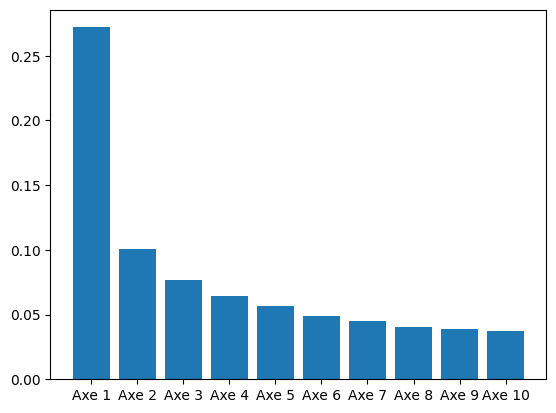

array([0.27194693, 0.37295231, 0.44947347, 0.51362694, 0.57032833,
       0.61930185, 0.66467752, 0.70520404, 0.74441162, 0.78145179])

In [25]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
cls = PCA(n_components=10) 
pcs = cls.fit_transform(data_scaled) 
cls.components_
plt.bar([f"Axe {i+1}" for i in range(10)], cls.explained_variance_ratio_) 
plt.show()
np.cumsum(cls.explained_variance_ratio_)

In [7]:

def add_labels(x, y, labels, ax=None):
    """Ajoute les étiquettes `labels` aux endroits définis par `x` et `y`."""

    if ax is None:
        ax = plt.gca()
    for x, y, label in zip(x, y, labels):
        ax.annotate(
            label, [x, y], xytext=(10, -5), textcoords="offset points",
        )

    return ax

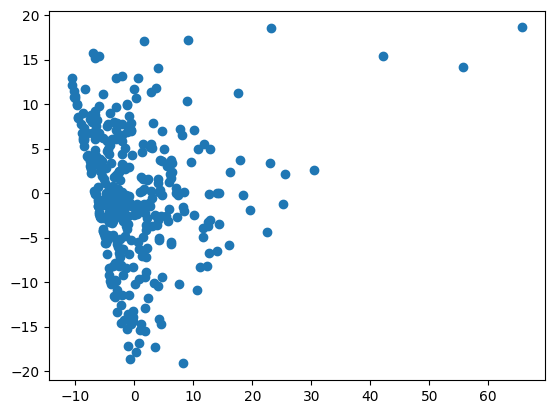

In [8]:
# Représentation dans le premier plan factoriel
plt.scatter(pcs[:, 0], pcs[:, 1]) 
# add_labels(pcs[:, 0], pcs[:, 1], data.index) 
plt.show()

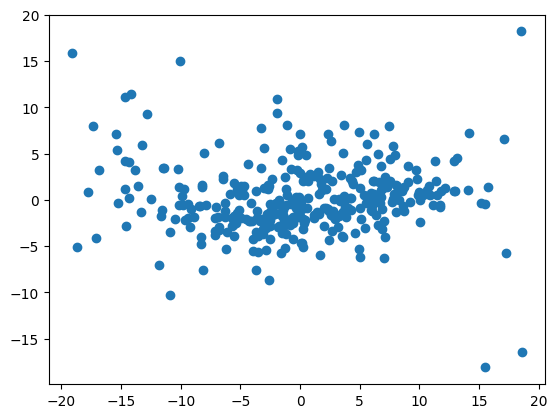

In [9]:
# Représentation dans le deuxième plan factoriel
plt.scatter(pcs[:, 1], pcs[:, 2]) 
plt.show()

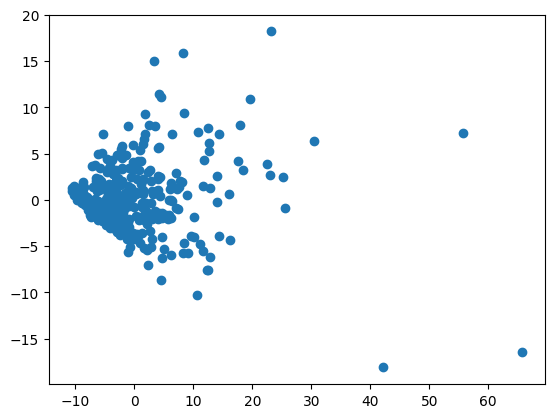

In [10]:
# Représentation dans le troisième plan factoriel
plt.scatter(pcs[:, 0], pcs[:, 2]) 
plt.show()

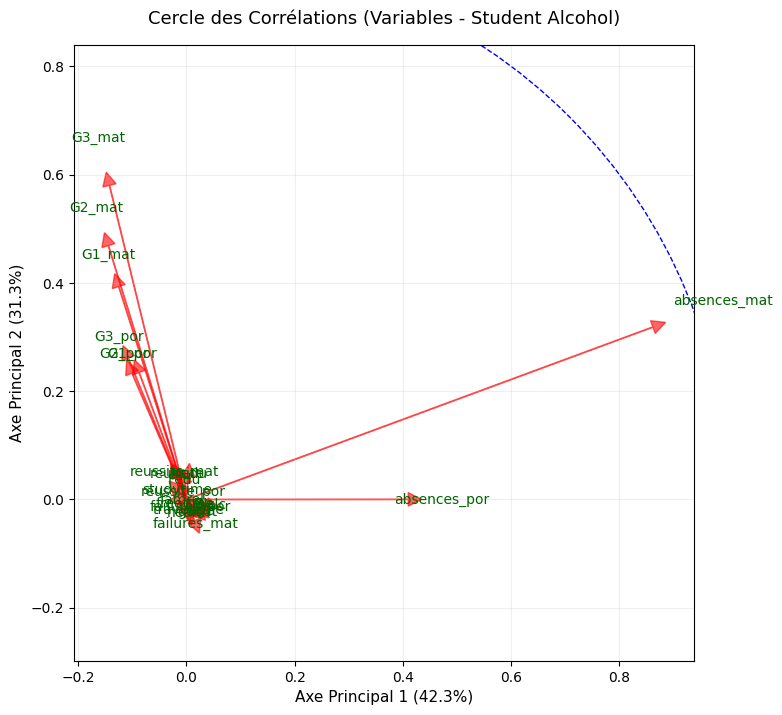

In [11]:

modele_acp = cls

loadings_axes = modele_acp.components_
variables_names = data.columns

fig, ax = plt.subplots(figsize=(8, 8))

for i, col_name in enumerate(variables_names):
    x_val = loadings_axes[0, i]
    y_val = loadings_axes[1, i]
    

    ax.arrow(0, 0, x_val, y_val, head_width=0.025, head_length=0.025, color='red', alpha=0.6)
    

    ax.text(x_val * 1.15, y_val * 1.15, col_name, color='darkgreen', ha='center', va='center', fontsize=10)


cercle_unite = plt.Circle((0,0), 1, color='blue', fill=False, linestyle='--')
ax.add_artist(cercle_unite)


var_exp = modele_acp.explained_variance_ratio_
plt.xlabel(f"Axe Principal 1 ({var_exp[0]*100:.1f}%)", fontsize=11)
plt.ylabel(f"Axe Principal 2 ({var_exp[1]*100:.1f}%)", fontsize=11)

plt.title("Cercle des Corrélations (Variables - Student Alcohol)", fontsize=13, pad=15)
plt.grid(True, alpha=0.2)
plt.axis('equal')
plt.show()

In [12]:

coefficients = cls.components_[:5, :]

axes_noms = []
for i in range(5):
    variance_pct = cls.explained_variance_ratio_[i] * 100
    axes_noms.append(f"Axe {i+1} ({variance_pct:.1f}%)")

tableau_pca = pd.DataFrame(
    coefficients.T, 
    columns=axes_noms, 
    index=data.columns
)
tableau_pca.round(3).style.background_gradient(cmap='coolwarm', axis=0)

,Axe 1 (42.3%),Axe 2 (31.3%),Axe 3 (8.7%),Axe 4 (6.5%),Axe 5 (1.6%)
age,0.023000,-0.018000,-0.002000,0.036000,0.116000
Medu,0.004000,0.042000,0.006000,0.024000,0.058000
Fedu,-0.003000,0.031000,0.021000,0.013000,0.093000
traveltime,0.003000,-0.016000,-0.004000,-0.021000,0.020000
studytime,-0.015000,0.016000,-0.005000,0.071000,0.044000
failures_mat,0.015000,-0.039000,0.009000,-0.021000,-0.021000
famrel,-0.007000,-0.000000,-0.005000,0.001000,-0.041000
freetime,-0.003000,-0.006000,0.003000,-0.052000,0.009000
goout,0.018000,-0.020000,0.019000,-0.022000,-0.049000
Dalc,0.022000,-0.009000,-0.006000,-0.088000,-0.009000


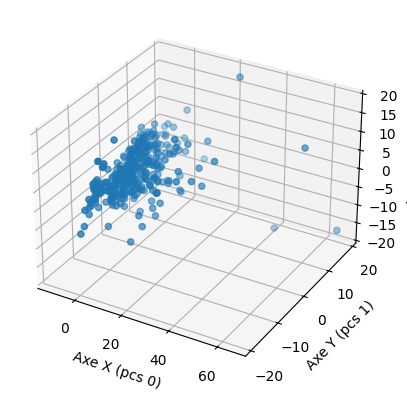

In [13]:
# Visualisation en 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(pcs[:, 0], pcs[:, 1], pcs[:, 2])

ax.set_xlabel('Axe X (pcs 0)')
ax.set_ylabel('Axe Y (pcs 1)')
ax.set_zlabel('Axe Z (pcs 2)')

plt.show()

In [14]:
# En version interactive 3d
df = pd.DataFrame(pcs[:, :3], columns=['pcs 0', 'pcs 1', 'pcs 2'])

fig = px.scatter_3d(df, x='pcs 0', y='pcs 1', z='pcs 2')
fig.show()

In [15]:
# Transformation en distances (pour ensuite faire une AFTD dessus)
X = data.copy() 

# standardiser les données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calcul de la matrice de dissimilarité (avec la distance euclidienne)
matrice_dissimilarite = pairwise_distances(X_scaled, metric='euclidean')
df_distances = pd.DataFrame(matrice_dissimilarite, index=data.index, columns=data.index)

print(df_distances.head())

        0         2         3         4         5         6         7    \
0  0.000000  6.718588  5.650061  6.442256  4.527268  5.792594  7.298857   
2  6.718588  0.000000  7.287910  5.636571  6.033904  6.911771  5.399060   
3  5.650061  7.287910  0.000000  5.797789  5.173035  4.416440  8.055696   
4  6.442256  5.636571  5.797789  0.000000  5.741594  3.586685  4.839787   
5  4.527268  6.033904  5.173035  5.741594  0.000000  4.530542  5.434022   

        8         9         10   ...        650       653       654       656  \
0  5.625378  6.054192  5.384836  ...  11.098164  6.753560  7.835660  7.741999   
2  4.708441  7.918372  6.973358  ...   8.829724  7.078263  7.398682  8.789661   
3  6.069135  5.097474  5.097061  ...  10.392657  5.496485  6.148332  6.463176   
4  3.953358  7.063568  4.350352  ...   8.989205  6.629030  6.911748  8.208508   
5  5.546562  5.270460  5.154597  ...   9.656001  6.151544  5.918494  6.745928   

        658       660       663       664       665        666

c:\Users\ellen\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning:

The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.

c:\Users\ellen\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning:

The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.

c:\Users\ellen\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning:

The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.



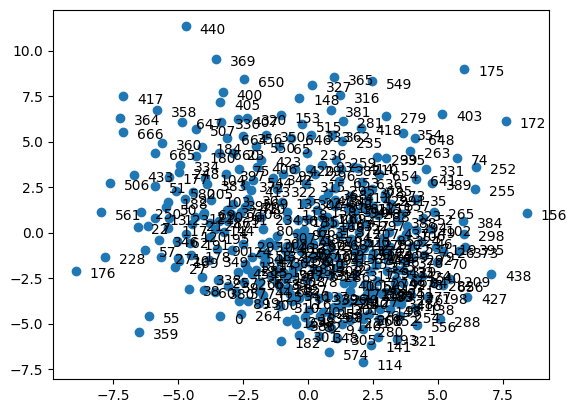

In [16]:
# AFTD
aftd = MDS(n_components=2, dissimilarity='precomputed') 
dist = aftd.fit_transform(df_distances)
plt.scatter(*dist.T) 
add_labels(dist[:, 0], dist[:, 1], df_distances.index) 
plt.show()

In [17]:
from scipy.spatial.distance import cdist
def plot_Shepard(mds_model, plot=True):
    """Affiche le diagramme de Shepard et retourne un couple contenant les
    dissimilarités originales et les distances apprises par le
    modèle.
    """

    assert isinstance(mds_model, MDS)

    # Inter-distances apprises
    dist = cdist(mds_model.embedding_, mds_model.embedding_)
    idxs = np.tril_indices_from(dist, k=-1)
    dist_mds = dist[idxs]

    # Inter-distances d'origine
    dist = mds_model.dissimilarity_matrix_
    dist_orig = dist[idxs]

    dists = np.column_stack((dist_orig, dist_mds))

    if plot:
        f, ax = plt.subplots()
        range = [dists.min(), dists.max()]
        ax.plot(range, range, 'r--')
        ax.scatter(*dists.T)
        ax.set_xlabel('Dissimilarités')
        ax.set_ylabel('Distances')

    return (*dists.T,)

c:\Users\ellen\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning:

The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.

c:\Users\ellen\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning:

The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.

c:\Users\ellen\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning:

The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.



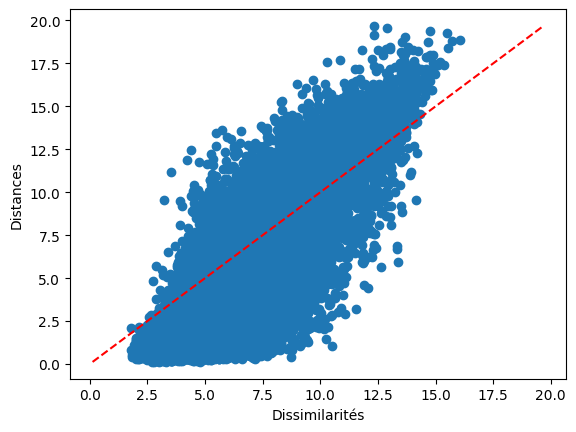

In [18]:
aftd = MDS(n_components=2, dissimilarity='precomputed') 
dist = aftd.fit_transform(df_distances) 
plot_Shepard(aftd) 
plt.show()

c:\Users\ellen\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning:

The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.

c:\Users\ellen\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning:

The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.

c:\Users\ellen\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning:

The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.



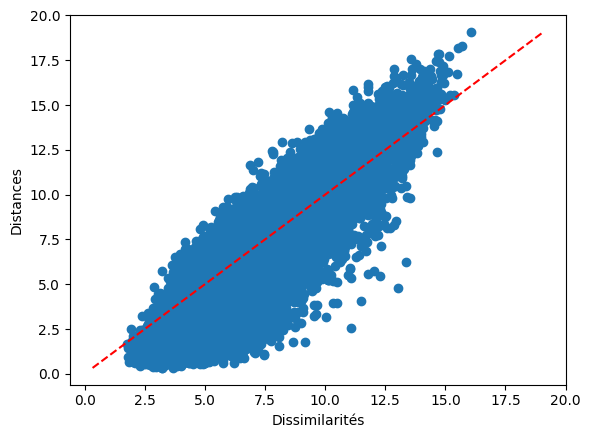

In [19]:
aftd = MDS(n_components=3, dissimilarity='precomputed') 
dist = aftd.fit_transform(df_distances) 
plot_Shepard(aftd) 
plt.show()

c:\Users\ellen\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning:

The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.

c:\Users\ellen\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning:

The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.

c:\Users\ellen\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning:

The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.



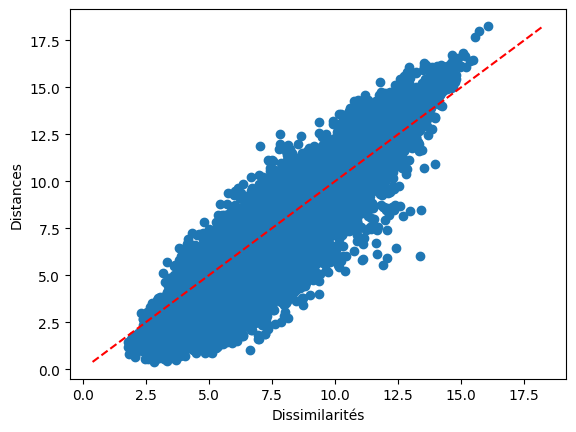

In [20]:
aftd = MDS(n_components=4, dissimilarity='precomputed') 
dist = aftd.fit_transform(df_distances) 
plot_Shepard(aftd) 
plt.show()

c:\Users\ellen\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning:

The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.

c:\Users\ellen\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning:

The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.

c:\Users\ellen\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning:

The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.



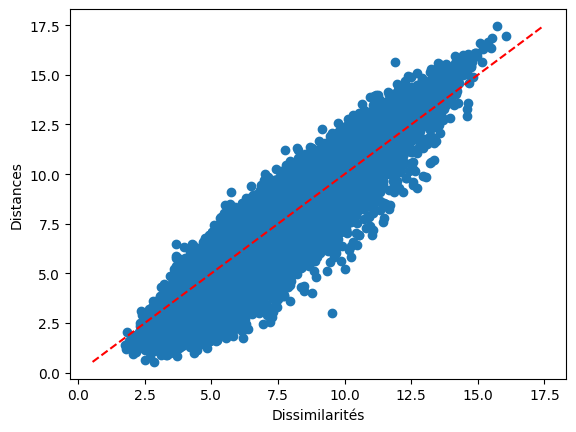

In [21]:
aftd = MDS(n_components=5, dissimilarity='precomputed') 
dist = aftd.fit_transform(df_distances) 
plot_Shepard(aftd) 
plt.show()

In [22]:
stress_shepard = aftd.stress_
print(f"Stress théorique = {stress_shepard}")
diss, dist = plot_Shepard(aftd, plot=False)
stress_exp = np.sum((diss - dist)**2)
print(f"Stress théorique = {stress_exp}")

Stress théorique = 48715.05212280734
Stress théorique = 48715.052122807334


In [23]:
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([model.children_, model.distances_,
                                      counts]).astype(float)

    # Plot the corresponding dendrogram
    default_kwargs = dict(leaf_font_size=10)
    default_kwargs.update(kwargs or {})
        
    dendrogram(linkage_matrix, **default_kwargs)


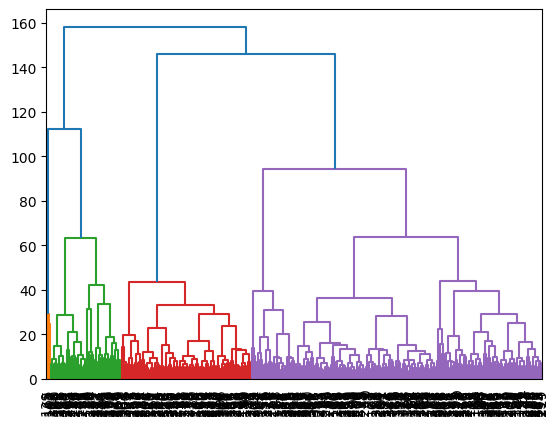

In [24]:
# CAH
cls = AgglomerativeClustering( metric="euclidean", linkage="ward", distance_threshold=0,n_clusters=None)
cls.fit(data)
plot_dendrogram(cls)
plt.show()